In [1]:
import matplotlib.pyplot as plt  
import seaborn as sns 
import pandas as pd
import numpy as np

#--------------------------------------------------------------------------------------------------------#
# Plots Análisis Exploratorio
def plot_temporal(df, columna: str, color: str='blue', marker: str='o', ax=None,
                  warning_min=None, warning_max=None, critical_min=None, critical_max=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))
    d = df.copy()
    d['date_time'] = pd.to_datetime(d['date_time'], errors='coerce')
    ax.plot(d['date_time'], d[columna], color=color, marker=marker, markersize=3, linewidth=1)
    # Líneas de límites si existen
    if warning_min is not None:
        ax.axhline(warning_min, color='orange', linestyle='--', label='Warning Min')
    if warning_max is not None:
        ax.axhline(warning_max, color='orange', linestyle='--', label='Warning Max')
    if critical_min is not None:
        ax.axhline(critical_min, color='red', linestyle=':', label='Critical Min')
    if critical_max is not None:
        ax.axhline(critical_max, color='red', linestyle=':', label='Critical Max')
    ax.set_title(f'{columna} vs fecha')
    ax.set_xlabel('fecha')
    ax.set_ylabel(columna)
    ax.grid(True)
    # Mostrar leyenda solo si hay límites
    if any(x is not None for x in [warning_min, warning_max, critical_min, critical_max]):
        ax.legend()
    if ax is None:  # retrocompat
        plt.tight_layout(); plt.show()

def plot_avg_hora(df, columna: str, color: str='skyblue', ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    d = df.copy()
    d['date_time'] = pd.to_datetime(d['date_time'], errors='coerce')
    d['hour'] = d['date_time'].dt.hour
    avg_by_hour = d.groupby('hour', as_index=False)[columna].mean()
    sns.barplot(x='hour', y=columna, data=avg_by_hour, color=color, ax=ax)
    ax.set_title(f'Promedio de {columna} por Hora')
    ax.set_xlabel('Hora del Día')
    ax.set_ylabel(f'Promedio {columna}')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    if ax is None:
        plt.tight_layout(); plt.show()

def plot_densidad(df, columna: str, color: str='purple', ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    sns.kdeplot(df[columna], color=color, fill=True, linewidth=2, ax=ax)
    ax.set_title(f'Densidad de {columna}')
    ax.set_xlabel(columna)
    ax.set_ylabel('Densidad')
    ax.grid(True, linestyle='--', alpha=0.7)
    if ax is None:
        plt.tight_layout(); plt.show()

def heatmap_hour(df, columna: str, agg: str='mean', ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))
    d = df.copy()
    d['date_time'] = pd.to_datetime(d['date_time'], errors='coerce')
    d = d.dropna(subset=['date_time'])
    d['hour'] = d['date_time'].dt.hour
    d['dow_num'] = d['date_time'].dt.dayofweek
    dow_labels = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
    pivot = d.pivot_table(index='dow_num', columns='hour', values=columna, aggfunc=agg)
    sns.heatmap(pivot, annot=False, cbar=True, ax=ax)
    ax.set_title(f'{agg.capitalize()} de {columna} por Hora y Día de la semana')
    ax.set_xlabel('Hora del día')
    ax.set_ylabel('Día de la semana')
    ax.set_yticks([i + 0.5 for i in range(7)])
    ax.set_yticklabels(dow_labels, rotation=0)
    if ax is None:
        plt.tight_layout(); plt.show()

def plot_corr(df):
    corr = df.select_dtypes(include='number').corr()
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)

    plt.title('Mapa de Correlación entre Variables Numéricas')
    plt.show()

def plot_all(df, columna: str,
             color_temporal='blue', marker_temporal='o',
             color_avg='skyblue', color_densidad='purple',
             agg_heatmap='mean',
             warning_min=None, warning_max=None, critical_min=None, critical_max=None,
             desc_df=None):   # <-- NUEVO parámetro opcional
    # --- NUEVO: si no me diste límites, los intento sacar de desc_df ---
    if desc_df is not None:
        row = desc_df[desc_df['name'] == columna]
        if not row.empty:
            def sg(col):
                v = row.iloc[0][col] if col in row else None
                return v if pd.notna(v) else None
            if warning_min  is None: warning_min  = sg('warning_min_value')
            if warning_max  is None: warning_max  = sg('warning_max_value')
            if critical_min is None: critical_min = sg('critical_min_value')
            if critical_max is None: critical_max = sg('critical_max_value')
    # -------------------------------------------------------------------

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    plt.subplots_adjust(hspace=0.35, wspace=0.25)

    plot_temporal(df, columna, color_temporal, marker_temporal, ax=axes[0, 0],
                  warning_min=warning_min, warning_max=warning_max,
                  critical_min=critical_min, critical_max=critical_max)

    plot_avg_hora(df, columna, color_avg, ax=axes[0, 1])
    plot_densidad(df, columna, color_densidad, ax=axes[1, 0])
    heatmap_hour(df, columna, agg_heatmap, ax=axes[1, 1])

    plt.tight_layout()
    plt.show()

def plot_all_timeseries(df):
    num_cols = df.select_dtypes(include=[np.number]).columns
    if 'date_time' not in df.columns:
        raise ValueError("El DataFrame debe tener una columna 'date_time'.")
    fig, axs = plt.subplots(len(num_cols), 1, figsize=(12, 3*len(num_cols)), sharex=True)
    if len(num_cols) == 1:
        axs = [axs]
    for i, col in enumerate(num_cols):
        axs[i].plot(df['date_time'], df[col], label=col)
        axs[i].set_ylabel(col)
        axs[i].legend(loc='upper right')
    plt.xlabel('date_time')
    plt.show()

In [2]:
planta ="synthetic_data/synthetic_plant.csv"
planta_df = pd.read_csv(planta)

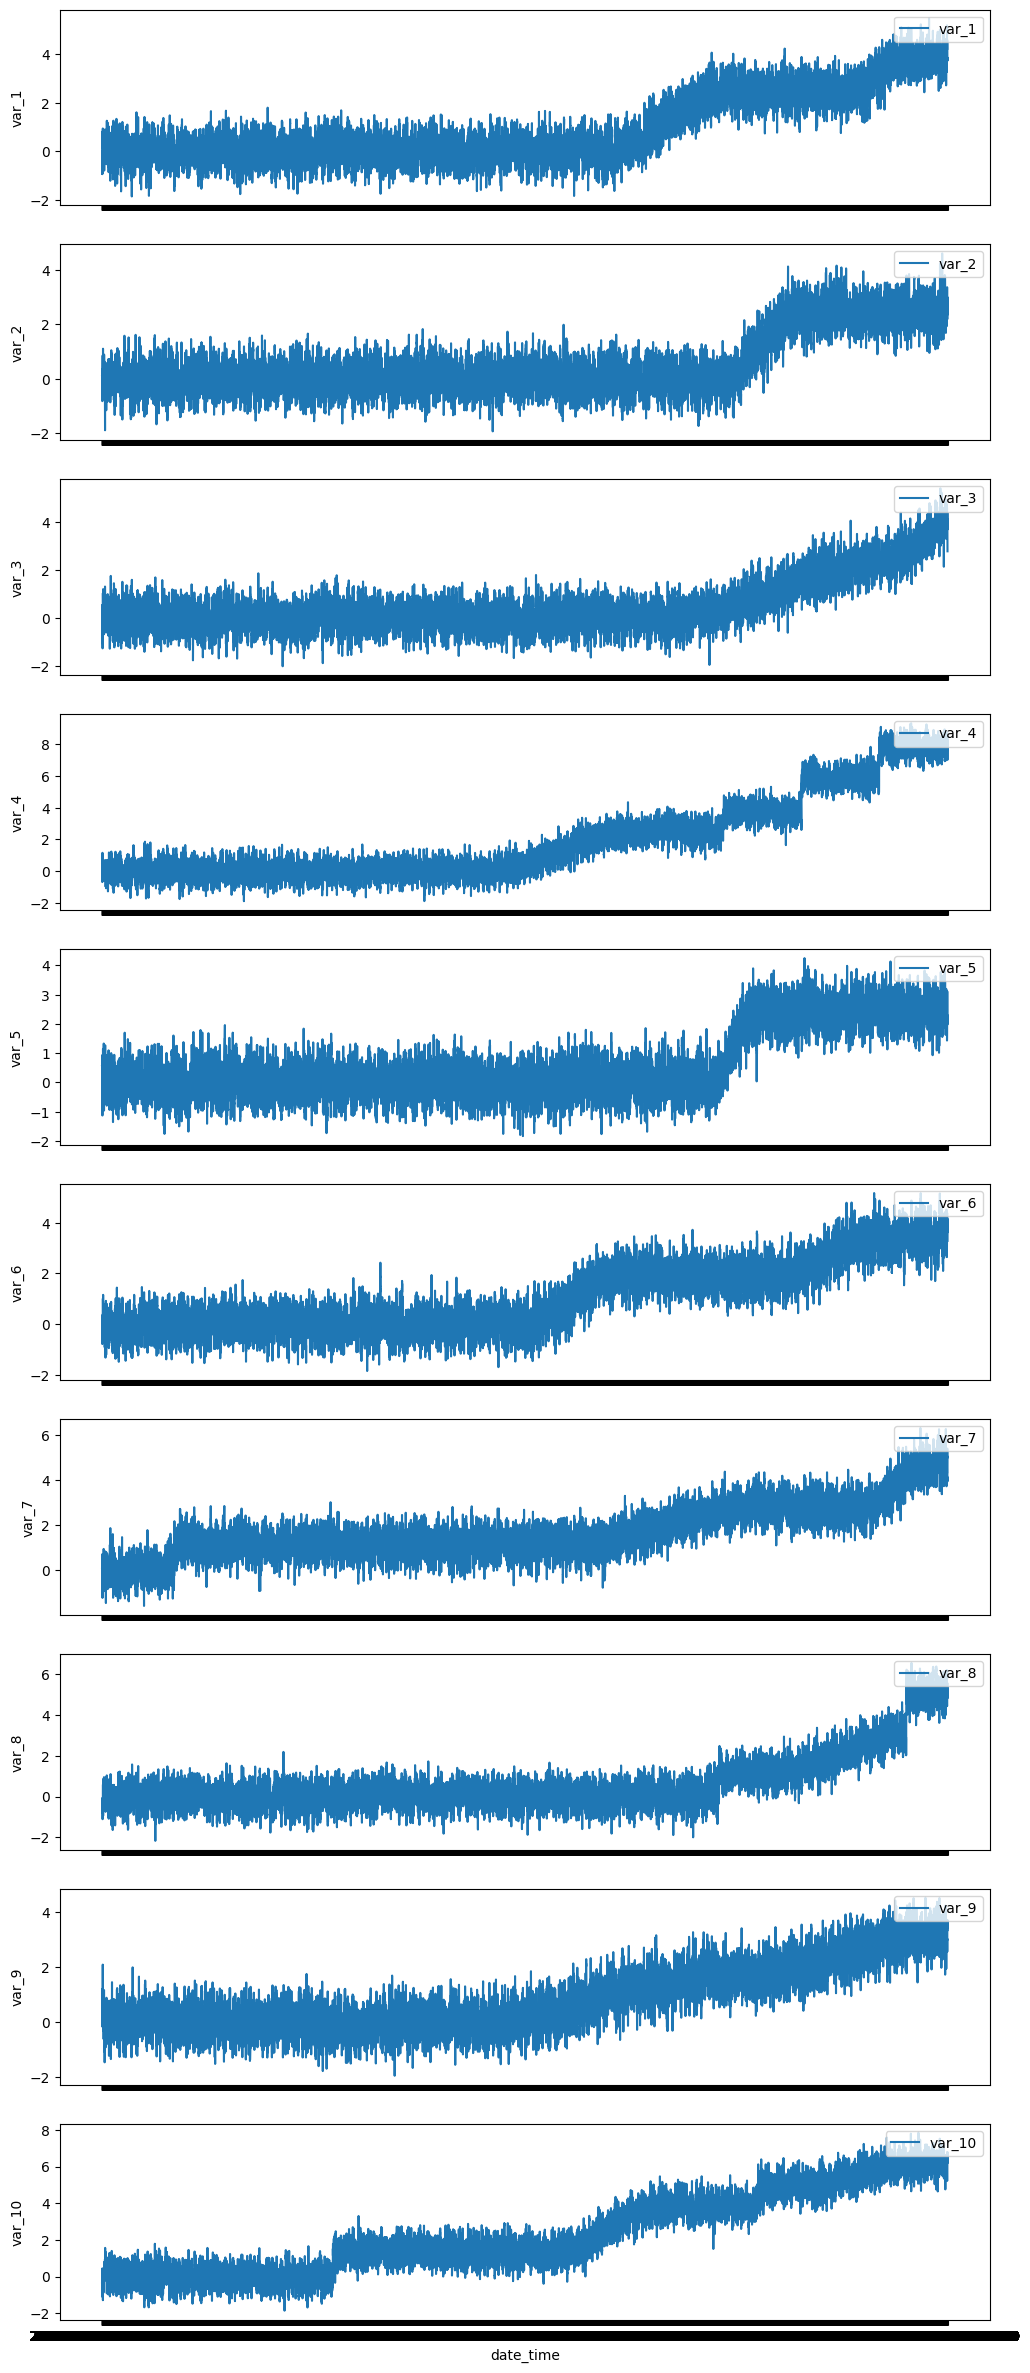

In [3]:
plot_all_timeseries(planta_df)

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# === 1. Leer CSV ===
path = Path("synthetic_data/results/eval_episodes_by_window_strategy.csv")
df = pd.read_csv(path)

# Crear etiqueta combo = método + estrategia
df["combo"] = df["metric"] + " – " + df["strategy"]

# Limpiar ventanas (remove H/h y convertir a int)
def clean_window(w):
    return int(str(w).lower().replace("h", "").strip())

df["window_clean"] = df["window"].apply(clean_window)

# Ordenar combos y ventanas
combo_order = sorted(df["combo"].unique())
window_order = sorted(df["window_clean"].unique())

# === 2. Crear pivotes (usar window_clean para ordenar, pero mostrar ventana original) ===
# obtener mapping window_clean -> window string original
win_map = df.groupby("window_clean")["window"].first().to_dict()

pivot_f1 = df.pivot_table(index="combo", columns="window_clean", values="F1").reindex(index=combo_order, columns=window_order)
pivot_f1_time = df.pivot_table(index="combo", columns="window_clean", values="F1_time").reindex(index=combo_order, columns=window_order)
pivot_f1_mix = df.pivot_table(index="combo", columns="window_clean", values="Score_F1_combined").reindex(index=combo_order, columns=window_order)

# Renombrar columnas a sus ventanas reales
pivot_f1.columns = [win_map[w] for w in pivot_f1.columns]
pivot_f1_time.columns = [win_map[w] for w in pivot_f1_time.columns]
pivot_f1_mix.columns = [win_map[w] for w in pivot_f1_mix.columns]

# === 3. Función para heatmap con valores dentro ===
def plot_heatmap_with_values(pivot, title, filename):
    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(pivot.values, aspect="auto", cmap="Blues")

    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
    ax.set_yticklabels(pivot.index)

    # Agregar valores dentro
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color="black")

    ax.set_xlabel("Tamaño de ventana")
    ax.set_ylabel("Estadístico + Estrategia")
    ax.set_title(title)

    fig.colorbar(im, ax=ax)
    plt.tight_layout()

    # Guardar en carpeta local (crea si no existe) en lugar de /mnt/data
    out_dir = (path.parent if 'path' in globals() else Path.cwd()) / "images"
    out_dir.mkdir(parents=True, exist_ok=True)
    out = out_dir / filename
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.close(fig)
    return str(out)

# === 4. Generar heatmaps ===
out1 = plot_heatmap_with_values(pivot_f1,      "F1 por ventana y estrategia",       "heatmap_F1.png")
out2 = plot_heatmap_with_values(pivot_f1_time, "F1_time por ventana y estrategia",  "heatmap_F1_time.png")
out3 = plot_heatmap_with_values(pivot_f1_mix,  "F1_mixto por ventana", "heatmap_F1_mixto.png")

[out1, out2, out3]


['synthetic_data\\results\\images\\heatmap_F1.png',
 'synthetic_data\\results\\images\\heatmap_F1_time.png',
 'synthetic_data\\results\\images\\heatmap_F1_mixto.png']

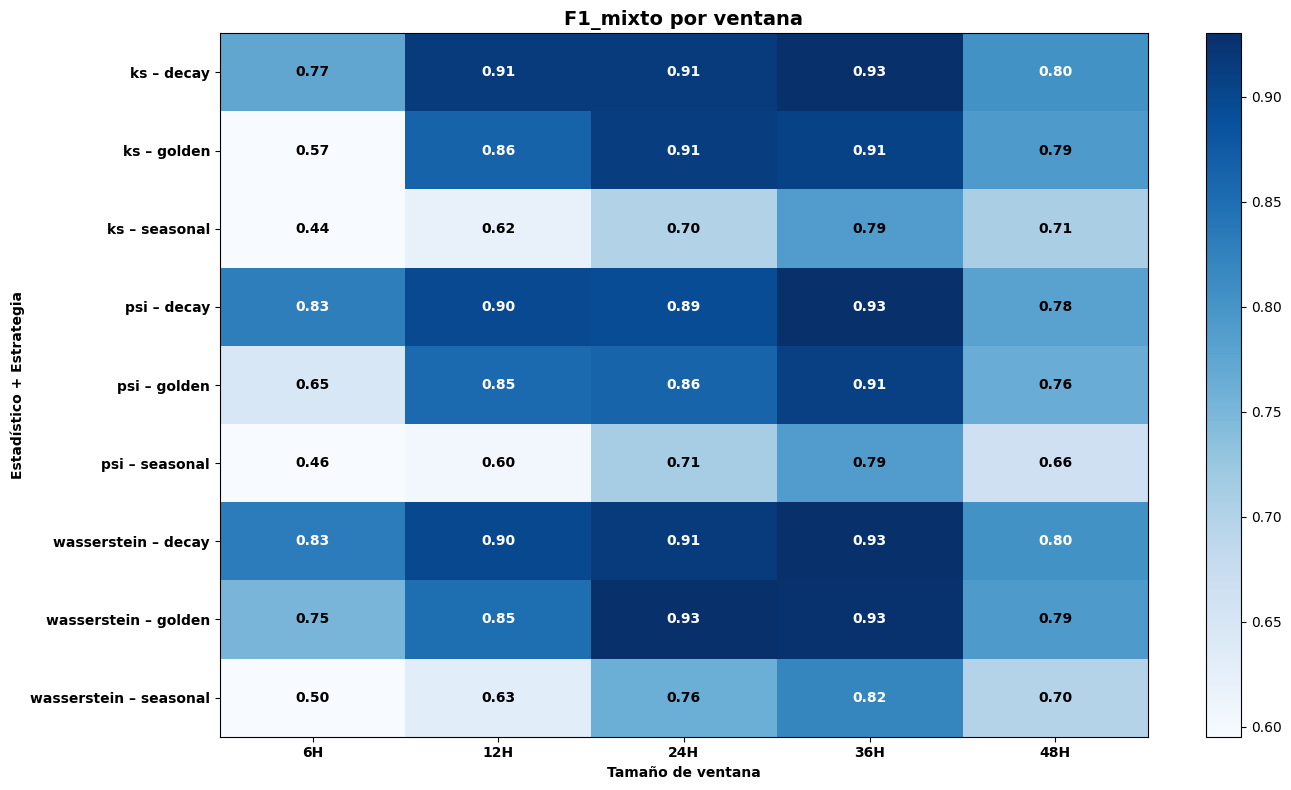

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Cargar datos ===
df = pd.read_csv('synthetic_data/results/eval_episodes_by_window_strategy.csv')

# === Calcular F1_mixto correcto ===
df["F1_mixto"] = 0.85 * df["F1"] + 0.15 * df["F1_time"]
df["combo"] = df["metric"] + " – " + df["strategy"]

# orden deseado de ventanas
window_order = ["6H", "12H", "24H", "36H", "48H"]
window_order = [w for w in window_order if w in df["window"].unique()]

heatmap_df = (
    df.pivot(index="combo", columns="window", values="F1_mixto")
      .reindex(columns=window_order)
      .sort_index()
)

# === Plot ===
plt.figure(figsize=(14, 8))

# Fijar rango de color (vmin, vmax) para mejorar contraste
vmin, vmax = heatmap_df.min().min(), heatmap_df.max().max()
im = plt.imshow(heatmap_df, cmap="Blues", aspect="auto", vmin=vmin*1.35, vmax=vmax)

# Valores sobre cada celda con color adaptativo
threshold = 0.8
for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        val = heatmap_df.iloc[i, j]
        text_color = 'white' if val > threshold else 'black'
        plt.text(j, i, f"{val:.2f}", ha='center', va='center', 
                color=text_color, fontweight='bold', fontsize=10)

plt.colorbar(im)
plt.title("F1_mixto por ventana", fontweight='bold', fontsize=14)
plt.ylabel("Estadístico + Estrategia", fontweight='bold')
plt.xlabel("Tamaño de ventana", fontweight='bold')
plt.xticks(ticks=np.arange(len(heatmap_df.columns)), labels=heatmap_df.columns, fontweight='bold')
plt.yticks(ticks=np.arange(len(heatmap_df.index)), labels=heatmap_df.index, fontweight='bold')
plt.tight_layout()
plt.show()
